# Test-Region Calculations

* Import
* Data preparation
* Calculations

In [6]:
import arcpy
# import rasterio
import os

from arcpy.sa import *
from arcpy.ia import *
from arcpy.da import *

# from rasterio.plot import show_hist, show

from matplotlib import pyplot

%matplotlib inline 


#### 2. Clip diff-raster with each region
* load raster 
* clip raster to the region of interest
* save output as raster file

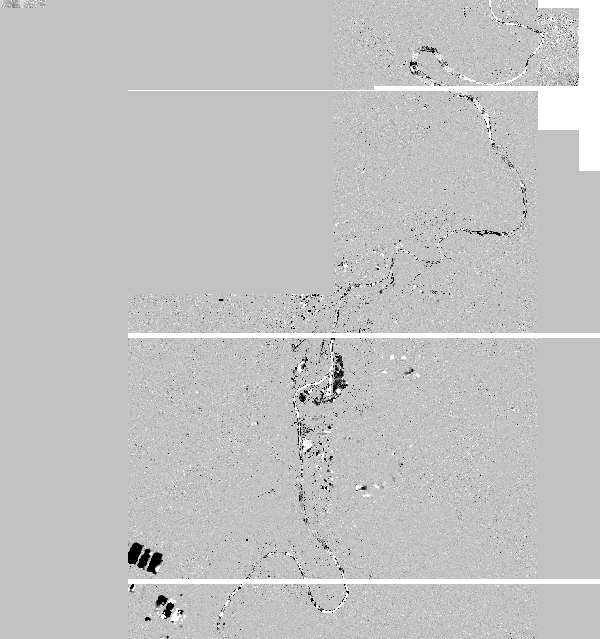

In [6]:
raster_1914 = r"F:\newData\testworkspace.gdb\copyraster1914"
area_of_interest = r"F:\newData\Pilotregionen\KasselStadt.shp"
output_file = r"F:\newData\diff19_14_Kassel.tif"

raster_1914_clip = Clip(raster_1914, area_of_interest) 
raster_1914_clip.save(output_file) 

Diff_21-19

In [7]:
raster_2119 = r"F:\newData\testworkspace.gdb\copyraster2119_2"
area_of_interest = r"F:\newData\Pilotregionen\KasselStadt.shp"
output_file = r"F:\newData\diff21_19_Kassel.tif"

raster_2119_clip = Clip(raster_2119, area_of_interest) 
raster_2119_clip.save(output_file) 

#### 3. Calculate raster statistics
* calculate minimum | maximum  | mean | standard Deviation of the newly created raster and store them in variables for later use
* plot histogram of newly created raster to get an overview of the range of the values 

Diff_19-14

In [7]:
stats_min = raster_1914_clip.minimum
stats_max = raster_1914_clip.maximum
stats_mean = raster_1914_clip.mean
stats_std = raster_1914_clip.standardDeviation
print("Minimum: {0}, Maximum: {1}, Mean: {2}, Standard Deviation: {3}".format(stats_min, stats_max, stats_mean, stats_std))

Minimum: -12.510986328125, Maximum: 33.54199981689453, Mean: -0.005938445751411377, Standard Deviation: 0.16927515082500755


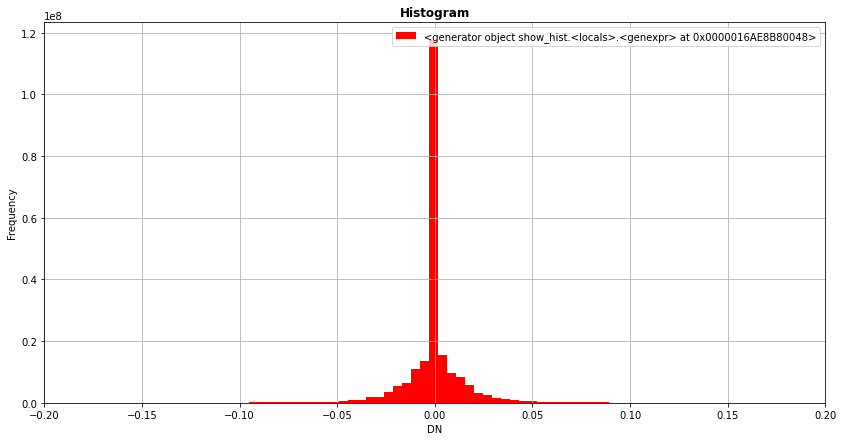

In [43]:
#inp_raster = r"F:\newData\diff19_14_Kassel.tif"
#min_value = -0.2
#max_value = 0.2

#fig, ax1 = pyplot.subplots(1, 1, figsize=(14,7))
#src = rasterio.open(inp_raster)
#show_hist(src, bins=10000, lw=0.0, stacked=False, histtype='bar', title="Histogram", ax=ax1)
#ax1.set_xlim(xmin=min_value, xmax=max_value)
#pyplot.show()

Diff_21-19

In [8]:
stats_min = raster_2119_clip.minimum
stats_max = raster_2119_clip.maximum
stats_mean = raster_2119_clip.mean
stats_std = raster_2119_clip.standardDeviation
print("Minimum: {0}, Maximum: {1}, Mean: {2}, Standard Deviation: {3}".format(stats_min, stats_max, stats_mean, stats_std))

Minimum: -22.069000244140625, Maximum: 62.832000732421875, Mean: 0.03702182813448644, Standard Deviation: 0.345058912269862


In [ ]:
#inp_raster = r"F:\newData\diff21_19_Kassel.tif"
#min_value = -0.2
#max_value = 0.2

#fig, ax1 = pyplot.subplots(1, 1, figsize=(14,7))
#src = rasterio.open(inp_raster)
#show_hist(src, bins=10000, lw=0.0, stacked=False, histtype='bar', title="Histogram", ax=ax1)
#ax1.set_xlim(xmin=min_value, xmax=max_value)
#pyplot.show()

#### 4. Reclassify Raster for later use
* Copy and Save Raster 
* create a range for the reclassification
* reclassify based on one value and new range 
* save the reclassified raster

diff_19-14

In [46]:
inp_raster = r"F:\newData\diff19_14_Kassel.tif"
out_raster = r"F:\newData\diff1914_K_re.tif"

arcpy.management.CopyRaster(inp_raster, out_raster)

<Result 'F:\\newData\\diff1914_K_re.tif'>

In [57]:
inp_raster = r"F:\newData\diff1914_K_re.tif"
out_raster = r"F:\newData\diff1914_K_re1.tif"

range_class = RemapRange([[stats_min, -1,-1],[-1,1,"NODATA"],[1, stats_max,1]])

raster_reclas = Reclassify(inp_raster, "Value", range_class)
raster_reclas.save(out_raster)

In [58]:
inp_raster = r"F:\newData\diff1914_K_re.tif"
out_raster = r"F:\newData\diff1914_K_re2.tif"

range_class = RemapRange([[stats_min, -5,-5],[-5,-2.5,-2],[-2.5,-1.5,-1],[-1.5,-0.1,0],[-0.1,0.1,"NODATA"],[0.1,1.5,0],[1.5,2.5,1],[2.5,5,2],[5, stats_max,5]])

raster_reclas = Reclassify(inp_raster, "Value", range_class)
raster_reclas.save(out_raster)

diff_21-19

In [10]:
inp_raster = r"F:\newData\diff21_19_Kassel.tif"
out_raster = r"F:\newData\diff2119_K_re.tif"

arcpy.management.CopyRaster(inp_raster, out_raster)

<Result 'F:\\newData\\diff2119_K_re.tif'>

In [11]:
inp_raster = r"F:\newData\diff2119_K_re.tif"
out_raster = r"F:\newData\diff2119_K_re1.tif"

range_class = RemapRange([[stats_min, -1,-1],[-1,1,"NODATA"],[1, stats_max,1]])

raster_reclas = Reclassify(inp_raster, "Value", range_class)
raster_reclas.save(out_raster)

In [12]:
inp_raster = r"F:\newData\diff2119_K_re.tif"
out_raster = r"F:\newData\diff2119_K_re2.tif"

range_class = RemapRange([[stats_min, -5,-5],[-5,-2.5,-2],[-2.5,-1.5,-1],[-1.5,-0.1,0],[-0.1,0.1,"NODATA"],[0.1,1.5,0],[1.5,2.5,1],[2.5,5,2],[5, stats_max,5]])

raster_reclas = Reclassify(inp_raster, "Value", range_class)
raster_reclas.save(out_raster)

#### 5. Clip Vector-Data to AOI

In [61]:
inp_vect = r"F:\newData\testworkspace.gdb\rasterUTM1x1"
area_of_int = r"F:\newData\Pilotregionen\KasselStadt.shp"
out_data = r"F:\newData\gridUTM1x1_Ka.shp"

vect_clip = arcpy.analysis.Clip(inp_vect, area_of_int, out_data)  

In [67]:
inp_path = r"F:\newData\hesse_shp"


osm_list = []
osm_names = []
walk = arcpy.da.Walk(inp_path, datatype="FeatureClass")

for dirpath, dirnames, filenames in walk:
    for filename in filenames:
        osm_list.append(os.path.join(dirpath, filename))
        osm_names.append(filename)
print(osm_names)

['gis_osm_buildings_a_free_1.shp', 'gis_osm_landuse_a_free_1.shp', 'gis_osm_natural_a_free_1.shp', 'gis_osm_natural_free_1.shp', 'gis_osm_places_a_free_1.shp', 'gis_osm_places_free_1.shp', 'gis_osm_pofw_a_free_1.shp', 'gis_osm_pofw_free_1.shp', 'gis_osm_pois_a_free_1.shp', 'gis_osm_pois_free_1.shp', 'gis_osm_railways_free_1.shp', 'gis_osm_roads_free_1.shp', 'gis_osm_traffic_a_free_1.shp', 'gis_osm_traffic_free_1.shp', 'gis_osm_transport_a_free_1.shp', 'gis_osm_transport_free_1.shp', 'gis_osm_waterways_free_1.shp', 'gis_osm_water_a_free_1.shp']


In [69]:
out_folder = r"F:/newData/hesse_shp_kassel/"

for i, j in zip(osm_list, osm_names):
    out_data = out_folder + j
    arcpy.analysis.Clip(i, area_of_int, out_data) 

In [74]:
inp_path = r"F:\Umwelt 4.0\BBD_Update_2021_Hessen.gdb"

bbd_list = []
bbd_names = []
walk = arcpy.da.Walk(inp_path, datatype="FeatureClass")

for dirpath, dirnames, filenames in walk:
    for filename in filenames:
        bbd_list.append(os.path.join(dirpath, filename))
        bbd_names.append(filename)
print(bbd_names)
print(bbd_list)

['Zeitreihe_DESC_066_07', 'Zeitreihe_DESC_066_12', 'Zeitreihe_DESC_066_11', 'Zeitreihe_DESC_066_09', 'Zeitreihe_DESC_066_08', 'Zeitreihe_DESC_139_06', 'Zeitreihe_DESC_139_07', 'Zeitreihe_DESC_139_08', 'Zeitreihe_DESC_139_09', 'Zeitreihe_DESC_139_10', 'Zeitreihe_DESC_139_11', 'Zeitreihe_DESC_168_09', 'Zeitreihe_DESC_168_08', 'Zeitreihe_DESC_168_07', 'BBD_2021_PSI_LOS_desc_mittlere_Geschwindigkeit', 'BBD_2021_PSI_LOS_asce_mittlere_Geschwindigkeit', 'Zeitreihe_ASCE_117_09', 'Zeitreihe_ASCE_117_08', 'Zeitreihe_ASCE_117_07', 'Zeitreihe_ASCE_117_06', 'Zeitreihe_ASCE_088_04', 'Zeitreihe_ASCE_015_08', 'Zeitreihe_ASCE_015_07', 'Zeitreihe_ASCE_015_06', 'Zeitreihe_ASCE_015_05', 'BBD_2021_PSI_Ost_West', 'BBD_2021_PSI_Vertikal']
['F:\\Umwelt 4.0\\BBD_Update_2021_Hessen.gdb\\Zeitreihe_DESC_066_07', 'F:\\Umwelt 4.0\\BBD_Update_2021_Hessen.gdb\\Zeitreihe_DESC_066_12', 'F:\\Umwelt 4.0\\BBD_Update_2021_Hessen.gdb\\Zeitreihe_DESC_066_11', 'F:\\Umwelt 4.0\\BBD_Update_2021_Hessen.gdb\\Zeitreihe_DESC_066_09

In [76]:
out_folder = r"F:/newData/BBD_kassel/"

for i, j in zip(bbd_list, bbd_names):
    out_data = out_folder + j + ".shp"
    arcpy.analysis.Clip(i, area_of_int, out_data) 
    #print(out_data)